# Loading the Dataset

In [95]:
!pip install scikit-learn pandas numpy shap fairlearn lime xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 3.9 MB/s eta 0:00:0000:01


In [96]:
!pip install --upgrade scikit-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 67.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 17.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.


In [97]:
!wget https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv -P /usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/

--2025-09-30 16:28:55--  https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2546489 (2.4M) [text/plain]
Saving to: ‘/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv.1’

compas-scores-two-y 100%[===================>]   2.43M  --.-KB/s    in 0.06s   

2025-09-30 16:28:55 (38.0 MB/s) - ‘/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv.1’ saved [2546489/2546489]



In [98]:
ls -lh /usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/

total 4.9M
-rw-r--r-- 1 root root 2.5M Sep 30 15:05 compas-scores-two-years.csv
-rw-r--r-- 1 root root 2.5M Sep 30 16:28 compas-scores-two-years.csv.1


In [99]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [100]:
# Define the file path
file_path = "/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display first few rows
df.head()

invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [101]:
df.shape

(7214, 53)

In [102]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [103]:
df.head()

invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


# Preprocessing

In [104]:
df["two_year_recid"].value_counts()
# recid rate 45.1%

two_year_recid
0    3963
1    3251
Name: count, dtype: int64

In [105]:
df["is_recid"].value_counts()

is_recid
0    3743
1    3471
Name: count, dtype: int64

In [106]:
(df['two_year_recid']==df['is_recid']).value_counts()

True     6994
False     220
Name: count, dtype: int64

### **Identifiers & Personal Information:**
1. **'id'** – Unique identifier for each individual in the dataset.  
2. **'name'** – Full name of the individual.  
3. **'first'** – First name of the individual.  
4. **'last'** – Last name of the individual.  
5. **'dob'** – Date of birth.  
6. **'sex'** – Gender of the individual (Male/Female).  
7. **'race'** – Ethnicity of the individual (e.g., African-American, Caucasian, etc.).  

In [107]:
df = pd.get_dummies(df, columns=['race'], drop_first=False, dtype=int)

In [108]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=int)

In [109]:
columns_to_drop = ['id','name','first','last','dob']

### **Demographic & Age Information:**
8. **'age'** – Age of the individual at the time of assessment.  
9. **'age_cat'** – Categorized age groups (e.g., 18-25, 26-45, 46+).  

In [110]:
df['age_cat'].value_counts()

age_cat
25 - 45            4109
Greater than 45    1576
Less than 25       1529
Name: count, dtype: int64

In [111]:
# Define age bins and labels
bins = [18, 25, 35, 45, float('inf')]  # 46+ uses infinity
labels = ['18-25', '26-35', '36-45', '46+']

# Create categorical age groups
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

In [112]:
df['age_group'].value_counts()

age_group
26-35    2581
18-25    1858
46+      1463
36-45    1309
Name: count, dtype: int64

In [113]:
# Convert to one-hot encoding with prefix "age_"
df = pd.get_dummies(df, columns=['age_group'], prefix='age', dtype=int)

In [114]:
df

invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,id,name,first,last,compas_screening_date,dob,age,age_cat,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Male,age_18-25,age_26-35,age_36-45,age_46+
0,1,miguel hernandez,miguel,hernandez,2013-08-14,1947-04-18,69,Greater than 45,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0,0,0,0,0,0,1,1,0,0,0,1
1,3,kevon dixon,kevon,dixon,2013-01-27,1982-01-22,34,25 - 45,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1,1,0,0,0,0,0,1,0,1,0,0
2,4,ed philo,ed,philo,2013-04-14,1991-05-14,24,Less than 25,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1,1,0,0,0,0,0,1,1,0,0,0
3,5,marcu brown,marcu,brown,2013-01-13,1993-01-21,23,Less than 25,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0,1,0,0,0,0,0,1,1,0,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,1973-01-22,43,25 - 45,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0,0,0,0,0,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,1992-07-17,23,Less than 25,0,7,0,0,0,-1.0,2013-11-22 05:18:27,2013-11-24 02:59:20,13016249CF10A,2013-11-22,NaN,1.0,F,Deliver Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,7,Medium,2013-11-23,Risk of Violence,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0,1,0,0,0,0,0,1,1,0,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,1993-03-25,23,Less than 25,0,3,0,0,0,-1.0,2014-01-31 07:13:54,2014-02-02 04:03:52,14001422CF10A,2014-01-31,NaN,1.0,F,Leaving the Scene of Accident,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,3,Low,2014-02-01,Risk of Violence,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0,1,0,0,0,0,0,1,1,0,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,1958-10-01,57,Greater than 45,0,1,0,0,0,-1.0,2014-01-13 05:48:01,2014-01-14 07:49:46,14000581CF10A,2014-01-13,NaN,1.0,F,Aggravated Battery / Pregnant,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-01-14,Risk of Violence,1,Low,2014-01-14,2014-01-

In [115]:
columns_to_drop += ['age', 'age_cat']

### **Criminal History & Prior Records:**
10. **'juv_fel_count'** – Number of juvenile felony convictions.  
11. **'juv_misd_count'** – Number of juvenile misdemeanor convictions.  
12. **'juv_other_count'** – Number of other juvenile offenses.  
13. **'priors_count'** – Total number of prior adult convictions.  

In [116]:
# columns_to_drop += ['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']

### **Current Case Information:**
14. **'compas_screening_date'** – Date when the COMPAS risk assessment was conducted.  
15. **'c_case_number'** – Unique identifier for the individual's criminal case.  
16. **'c_offense_date'** – Date of the current offense.  
17. **'c_arrest_date'** – Date of the arrest for the current charge.  
18. **'c_charge_degree'** – Severity of the current charge (M = Misdemeanor, F = Felony).  
19. **'c_charge_desc'** – Description of the current charge (e.g., 'Grand Theft', 'Drug Possession').  
20. **'c_days_from_compas'** – Number of days between COMPAS assessment and the current case.  

In [117]:
columns_to_drop += ['compas_screening_date','c_arrest_date','c_days_from_compas', 'c_case_number','c_offense_date', 'c_charge_desc']

In [118]:
df['c_charge_desc'].value_counts()

c_charge_desc
Battery                           1156
arrest case no charge             1137
Possession of Cocaine              474
Grand Theft in the 3rd Degree      425
Driving While License Revoked      200
                                  ... 
Possession of Alcohol Under 21       1
Issuing a Worthless Draft            1
Prostitution                         1
Present Proof of Invalid Insur       1
Structuring Transactions             1
Name: count, Length: 437, dtype: int64

### Was testing to see if we could one hot encode c_charge_desc. Conclusion: Too unpredictable as a feature to predict recidivism. c_charge_degree is a good enough feature to keep


In [119]:
# # Count total occurrences of each charge type
# charge_counts = df['c_charge_desc'].value_counts()

# # Filter out charge descriptions with fewer than 10 total cases
# valid_charges = charge_counts[charge_counts >= 10].index
# df_filtered = df[df['c_charge_desc'].isin(valid_charges)]

# # Recalculate total and recidivism cases for the filtered data
# charge_counts_filtered = df_filtered.groupby('c_charge_desc')['two_year_recid'].count()
# recid_counts_filtered = df_filtered.groupby('c_charge_desc')['two_year_recid'].sum()

# # Calculate recidivism percentage
# recid_percentage_filtered = (recid_counts_filtered / charge_counts_filtered) * 100

# # Get top 10 charge types with the highest recidivism percentage
# top_10_recid_filtered = recid_percentage_filtered.nlargest(10)

# # Display the result
# print(top_10_recid_filtered)

In [120]:
# # Get top 30 most common charge descriptions
# top_30 = df['c_charge_desc'].value_counts().nlargest(30).index

# # Create binary columns with "c_charge_" prefix
# for charge in top_30:
#     df[f'c_charge_{charge}'] = (df['c_charge_desc'] == charge).astype(int)

# # Create "Other" column
# df['c_charge_Other'] = (~df['c_charge_desc'].isin(top_30)).astype(int)

# # Drop the original column
# df = df.drop(columns=['c_charge_desc'])

In [121]:
df.groupby('two_year_recid')['c_charge_degree'].value_counts()

two_year_recid  c_charge_degree
0               F                  2384
                M                  1579
1               F                  2282
                M                   969
Name: count, dtype: int64

In [122]:
df = pd.get_dummies(df, columns=['c_charge_degree'], drop_first=True, dtype=int)

### **Jail Custody Information:**
21. **'c_jail_in'** – Date the individual was jailed for the current offense.  
22. **'c_jail_out'** – Date the individual was released from jail for the current offense.

In [123]:
# df = df.dropna(subset=['c_jail_in', 'c_jail_out'])

In [124]:
columns_to_drop += ['c_jail_in','c_jail_out']

### **Recidivism (Reoffense) Information:**
23. **'is_recid'** – 1 if the individual reoffended, 0 otherwise.  
24. **'two_year_recid'** – 1 if the individual reoffended within two years, 0 otherwise.  


In [125]:
# columns_to_drop += ['is_recid']
# columns_to_drop += ['two_year_recid']

### **Reoffense Case Details:**
25. **'r_case_number'** – Case number for the recidivism offense.  
26. **'r_offense_date'** – Date of the reoffense.  
27. **'r_arrest_date'** – Date of arrest for the reoffense.  
28. **'r_days_from_arrest'** – Days between the original offense and the reoffense.  
29. **'r_charge_degree'** – Severity of the reoffense (M = Misdemeanor, F = Felony).  
30. **'r_charge_desc'** – Description of the reoffense charge.  
31. **'r_jail_in'** – Jail entry date for the reoffense.  
32. **'r_jail_out'** – Jail exit date for the reoffense.  

In [126]:
columns_to_drop += ['r_case_number', 'r_offense_date', 'r_days_from_arrest', 'r_charge_degree', 'r_charge_desc', 'r_jail_in', 'r_jail_out']

### **Violent Recidivism Information:**
33. **'violent_recid'** – Number of times the individual has committed a violent reoffense.  
34. **'is_violent_recid'** – 1 if the individual committed a violent reoffense, 0 otherwise.  
35. **'vr_case_number'** – Case number for violent recidivism.  
36. **'vr_offense_date'** – Date of the violent reoffense.  
37. **'vr_charge_degree'** – Severity of the violent reoffense (M = Misdemeanor, F = Felony).  
38. **'vr_charge_desc'** – Description of the violent reoffense charge.  

In [127]:
df['is_violent_recid'].value_counts()

is_violent_recid
0    6395
1     819
Name: count, dtype: int64

In [128]:
df['vr_charge_degree'].value_counts()

vr_charge_degree
(M1)     344
(F3)     228
(F2)     162
(F1)      38
(M2)      19
(F7)      18
(MO3)      5
(F6)       4
(F5)       1
Name: count, dtype: int64

In [129]:
columns_to_drop += ['violent_recid', 'vr_case_number', 'vr_offense_date', 'vr_charge_degree', 'vr_charge_desc']

### **COMPAS Risk Assessment Scores:**
39. **'type_of_assessment'** – Type of risk assessment (e.g., General Recidivism, Violent Recidivism).  
40. **'decile_score'** – Risk score (1-10) predicting likelihood of recidivism.  
41. **'score_text'** – Categorical risk level based on 'decile_score' (Low, Medium, High).  
42. **'decile_score.1'** – Duplicate of 'decile_score'.  

In [130]:
columns_to_drop += ['type_of_assessment','decile_score', 'score_text', 'decile_score.1']

### **Violent Recidivism Risk Scores:**
43. **'v_type_of_assessment'** – Type of assessment for violent recidivism.  
44. **'v_decile_score'** – Risk score (1-10) predicting violent reoffense.  
45. **'v_score_text'** – Categorical risk level for violent recidivism (Low, Medium, High).  
46. **'v_screening_date'** – Date of the violent recidivism assessment.  

In [131]:
columns_to_drop += ['v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date']

### **Additional Features & Redundant Columns:**
47. **'days_b_screening_arrest'** – Days between arrest and COMPAS screening.  
48. **'priors_count.1'** – Duplicate of 'priors_count'.  
49. **'in_custody'** – Date when the person entered custody.  
50. **'out_custody'** – Date when the person left custody.  
51. **'start'** – Beginning of a time-based event (not clearly defined).  
52. **'end'** – End of a time-based event (not clearly defined).  
53. **'event'** – An unspecified event indicator.  


In [132]:
df.groupby('two_year_recid')['event'].value_counts()

two_year_recid  event
0               0        3817
                1         146
1               1        2616
                0         635
Name: count, dtype: int64

In [133]:
# df['total_prior_convictions'] = df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count'] + df['priors_count']

In [134]:
columns_to_drop += ['days_b_screening_arrest', 'priors_count.1','in_custody','out_custody','start','end','event']

In [135]:
columns_to_drop

['id',
 'name',
 'first',
 'last',
 'dob',
 'age',
 'age_cat',
 'compas_screening_date',
 'c_arrest_date',
 'c_days_from_compas',
 'c_case_number',
 'c_offense_date',
 'c_charge_desc',
 'c_jail_in',
 'c_jail_out',
 'r_case_number',
 'r_offense_date',
 'r_days_from_arrest',
 'r_charge_degree',
 'r_charge_desc',
 'r_jail_in',
 'r_jail_out',
 'violent_recid',
 'vr_case_number',
 'vr_offense_date',
 'vr_charge_degree',
 'vr_charge_desc',
 'type_of_assessment',
 'decile_score',
 'score_text',
 'decile_score.1',
 'v_type_of_assessment',
 'v_decile_score',
 'v_score_text',
 'v_screening_date',
 'days_b_screening_arrest',
 'priors_count.1',
 'in_custody',
 'out_custody',
 'start',
 'end',
 'event']

In [136]:
df = df.drop(columns=columns_to_drop,axis=1)

In [137]:
df = df.drop(columns = ['screening_date'])

In [138]:
df.columns

Index(['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
       'is_recid', 'is_violent_recid', 'two_year_recid',
       'race_African-American', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Native American', 'race_Other', 'sex_Male',
       'age_18-25', 'age_26-35', 'age_36-45', 'age_46+', 'c_charge_degree_M'],
      dtype='object')

In [139]:
df.head()

,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,is_violent_recid,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Male,age_18-25,age_26-35,age_36-45,age_46+,c_charge_degree_M
0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0
1,0,0,0,0,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0
2,0,0,1,4,1,0,1,1,0,0,0,0,0,1,1,0,0,0,0
3,0,1,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0


In [140]:
df.shape

(7214, 19)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   juv_fel_count          7214 non-null   int64
 1   juv_misd_count         7214 non-null   int64
 2   juv_other_count        7214 non-null   int64
 3   priors_count           7214 non-null   int64
 4   is_recid               7214 non-null   int64
 5   is_violent_recid       7214 non-null   int64
 6   two_year_recid         7214 non-null   int64
 7   race_African-American  7214 non-null   int64
 8   race_Asian             7214 non-null   int64
 9   race_Caucasian         7214 non-null   int64
 10  race_Hispanic          7214 non-null   int64
 11  race_Native American   7214 non-null   int64
 12  race_Other             7214 non-null   int64
 13  sex_Male               7214 non-null   int64
 14  age_18-25              7214 non-null   int64
 15  age_26-35              7214 non-null  

### Visualizing overlap between features and targets

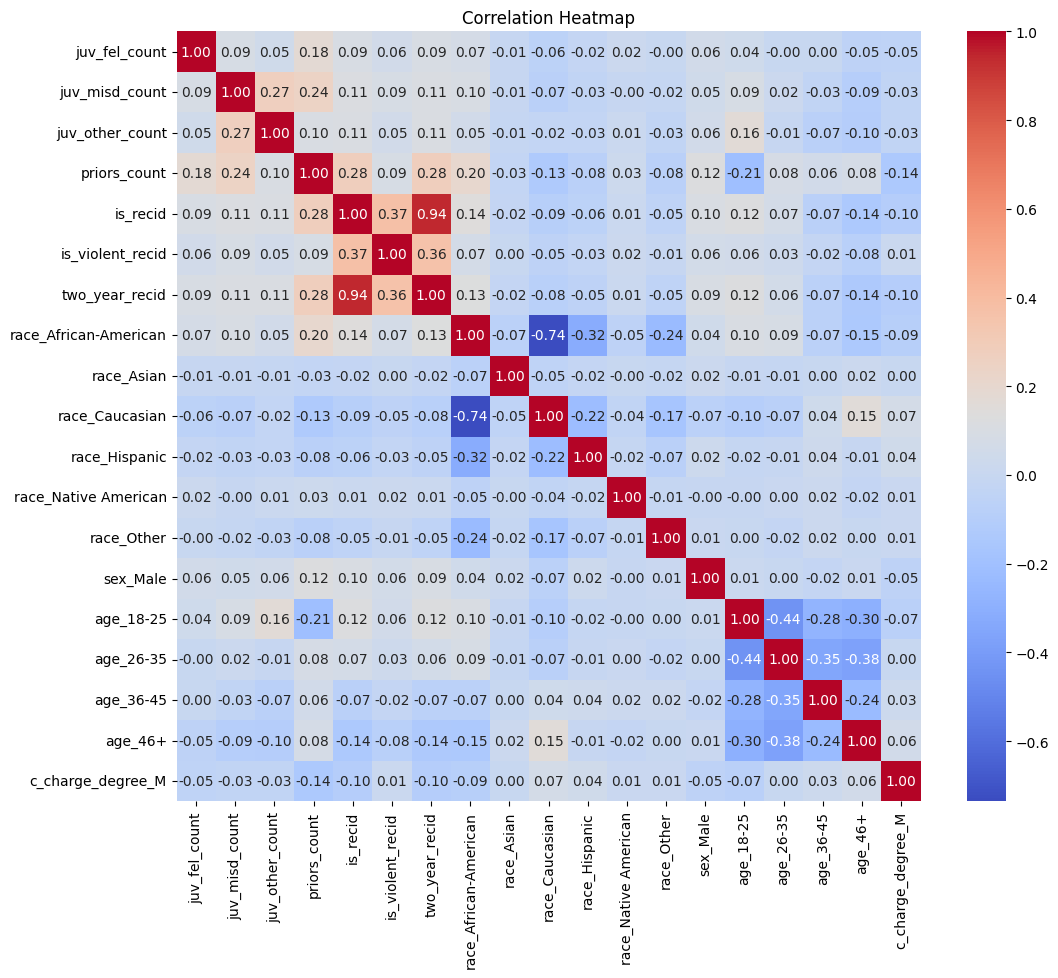

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Baseline models

## Train Test Split

In [143]:
X = df.drop(columns=['two_year_recid', 'is_recid', 'is_violent_recid'],axis=1)

In [144]:
y = df['two_year_recid']

In [145]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [146]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5771, 16), (1443, 16), (5771,), (1443,))

### XGB

In [147]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [148]:
model_1 = xgb.XGBClassifier(random_state=42)
model_1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [149]:
y_pred_1 = model_1.predict(X_test)

Accuracy: 0.6763686763686764
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73       823
           1       0.65      0.54      0.59       620

    accuracy                           0.68      1443
   macro avg       0.67      0.66      0.66      1443
weighted avg       0.67      0.68      0.67      1443

Confusion Matrix:
 [[642 181]
 [286 334]]


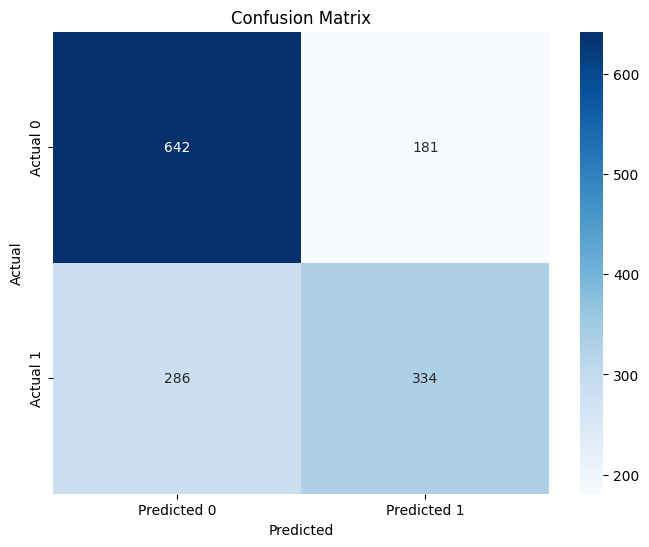

In [150]:
accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f"Accuracy: {accuracy_1}")

class_report_1 = classification_report(y_test, y_pred_1)
print("Classification Report:\n", class_report_1)

conf_matrix_1 = confusion_matrix(y_test, y_pred_1)
print("Confusion Matrix:\n", conf_matrix_1)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_1, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### SVC

In [151]:
from sklearn.svm import SVC
model_2 = SVC(random_state=42)
model_2.fit(X_train, y_train)

SVC(random_state=42)

In [152]:
y_pred_2 = model_2.predict(X_test)

Accuracy: 0.6923076923076923
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.81      0.75       823
           1       0.68      0.53      0.60       620

    accuracy                           0.69      1443
   macro avg       0.69      0.67      0.67      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[668 155]
 [289 331]]


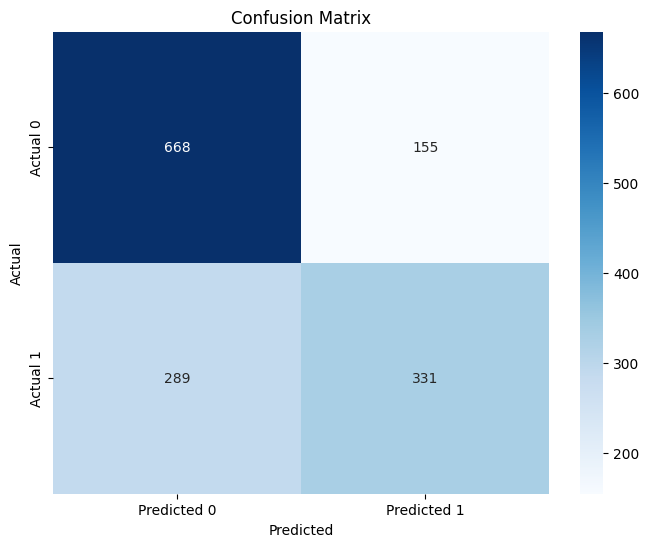

In [153]:
accuracy_2 = accuracy_score(y_test, y_pred_2)
print(f"Accuracy: {accuracy_2}")

class_report_2 = classification_report(y_test, y_pred_2)
print("Classification Report:\n", class_report_2)

conf_matrix_2 = confusion_matrix(y_test, y_pred_2)
print("Confusion Matrix:\n", conf_matrix_2)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_2, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic

In [154]:
from sklearn.linear_model import LogisticRegression
model_3 = LogisticRegression(random_state=42)
model_3.fit(X_train, y_train)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression(random_state=42)

In [155]:
y_pred_3 = model_3.predict(X_test)

Accuracy: 0.6812196812196812
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73       823
           1       0.64      0.59      0.61       620

    accuracy                           0.68      1443
   macro avg       0.67      0.67      0.67      1443
weighted avg       0.68      0.68      0.68      1443

Confusion Matrix:
 [[617 206]
 [254 366]]


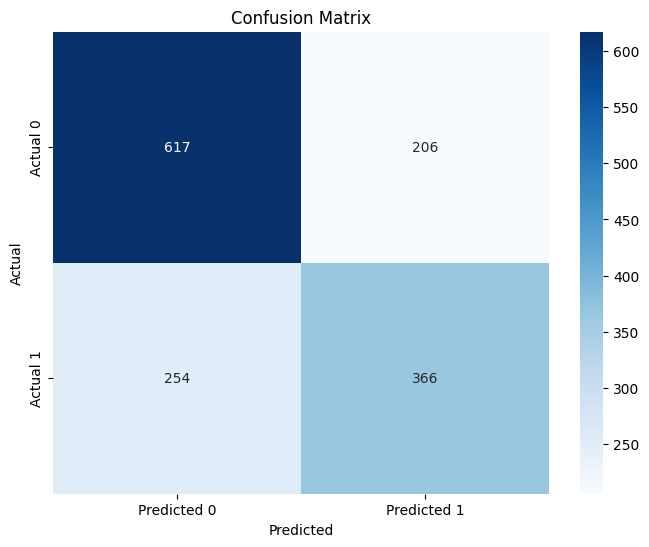

In [156]:
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Accuracy: {accuracy_3}")

class_report_3 = classification_report(y_test, y_pred_3)
print("Classification Report:\n", class_report_3)

conf_matrix_3 = confusion_matrix(y_test, y_pred_3)
print("Confusion Matrix:\n", conf_matrix_3)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_3, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### GBDT

In [157]:
from sklearn.ensemble import GradientBoostingClassifier

model_4 = GradientBoostingClassifier(random_state=42)
model_4.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [158]:
y_pred_4 = model_4.predict(X_test)

Accuracy: 0.6909216909216909
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74       823
           1       0.65      0.60      0.63       620

    accuracy                           0.69      1443
   macro avg       0.68      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[625 198]
 [248 372]]


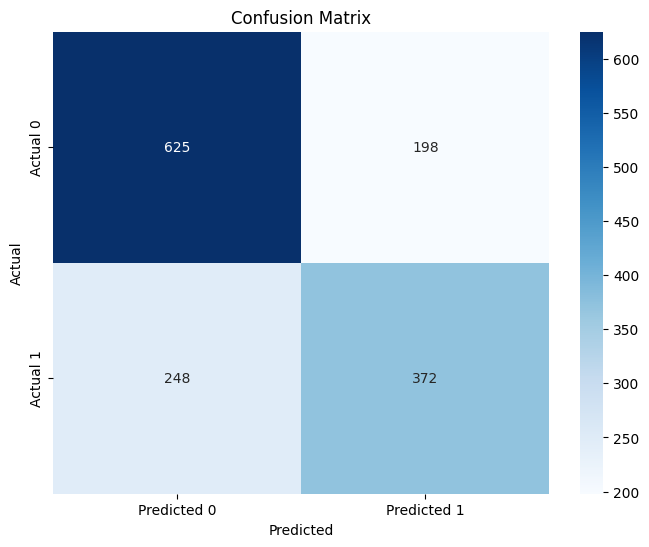

In [159]:
accuracy_4 = accuracy_score(y_test, y_pred_4)
print(f"Accuracy: {accuracy_4}")

class_report_4 = classification_report(y_test, y_pred_4)
print("Classification Report:\n", class_report_4)

conf_matrix_4 = confusion_matrix(y_test, y_pred_4)
print("Confusion Matrix:\n", conf_matrix_4)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_4, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### RFC

In [160]:
from sklearn.ensemble import RandomForestClassifier

model_5 = RandomForestClassifier(random_state=42)
model_5.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [161]:
y_pred_5 = model_5.predict(X_test)

Accuracy: 0.6507276507276507
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71       823
           1       0.61      0.51      0.56       620

    accuracy                           0.65      1443
   macro avg       0.64      0.63      0.63      1443
weighted avg       0.65      0.65      0.65      1443

Confusion Matrix:
 [[623 200]
 [304 316]]


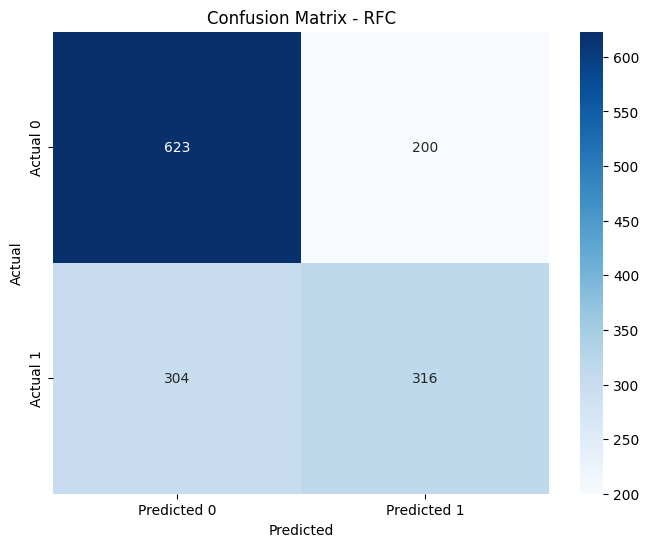

In [162]:
accuracy_5 = accuracy_score(y_test, y_pred_5)
print(f"Accuracy: {accuracy_5}")

class_report_5 = classification_report(y_test, y_pred_5)
print("Classification Report:\n", class_report_5)

conf_matrix_5 = confusion_matrix(y_test, y_pred_5)
print("Confusion Matrix:\n", conf_matrix_5)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_5, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - RFC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### NN (MLPClassifier)

In [163]:
from sklearn.neural_network import MLPClassifier

model_6 = MLPClassifier(random_state=42, max_iter=500)
model_6.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [164]:
y_pred_6 = model_6.predict(X_test)

Accuracy: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.67      0.55      0.60       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443

Confusion Matrix:
 [[656 167]
 [282 338]]


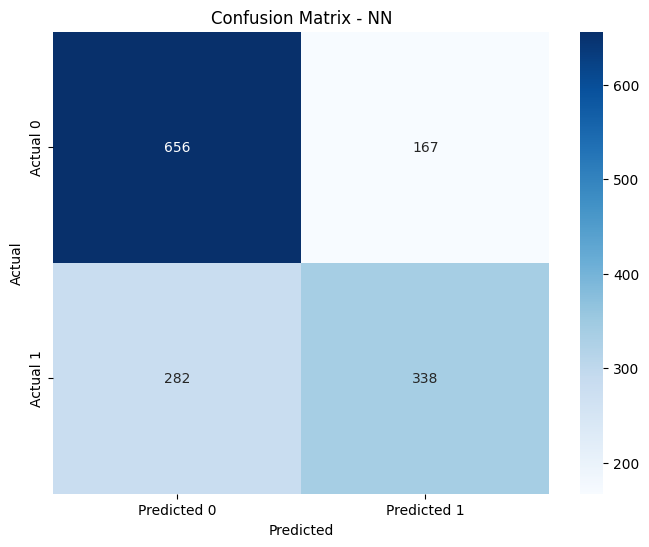

In [165]:
accuracy_6 = accuracy_score(y_test, y_pred_6)
print(f"Accuracy: {accuracy_6}")

class_report_6 = classification_report(y_test, y_pred_6)
print("Classification Report:\n", class_report_6)

conf_matrix_6 = confusion_matrix(y_test, y_pred_6)
print("Confusion Matrix:\n", conf_matrix_6)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_6, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - NN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# RandomizedSearchCV Hyperparameter Tuning

### XGB

Best XGBoost Parameters: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Accuracy with Best XGBoost Parameters: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.74       823
           1       0.65      0.60      0.62       620

    accuracy                           0.69      1443
   macro avg       0.68      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[625 198]
 [251 369]]


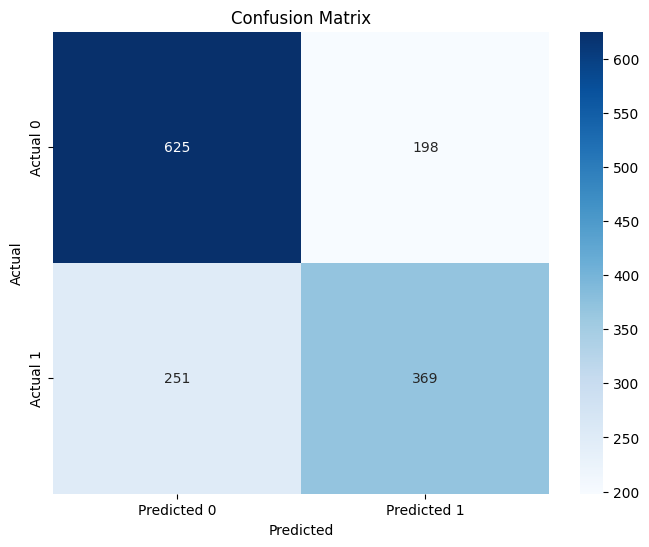

In [75]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(model_1, xgb_param_grid, scoring='accuracy', n_iter=100, cv=5, n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy with Best XGBoost Parameters: {accuracy_xgb}")

class_report_xgb = classification_report(y_test, y_pred_xgb)
print("Classification Report:\n", class_report_xgb)

conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", conf_matrix_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVC

Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 50}
Accuracy with Best SVM Parameters: 0.6909216909216909
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.54      0.60       620

    accuracy                           0.69      1443
   macro avg       0.69      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443

Confusion Matrix:
 [[662 161]
 [285 335]]


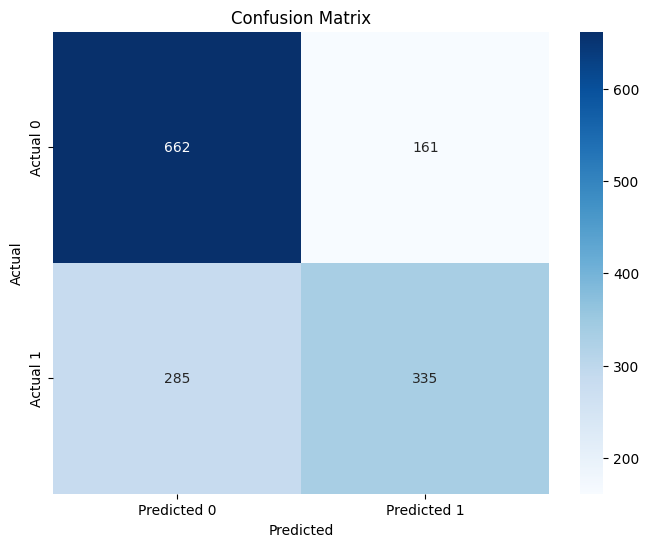

In [76]:
from sklearn.model_selection import RandomizedSearchCV

svm_param_dist = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svm_search = RandomizedSearchCV(model_2, svm_param_dist, n_iter=20, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

svm_search.fit(X_train, y_train)

print("Best SVM Parameters:", svm_search.best_params_)
best_svc = svm_search.best_estimator_
y_pred_svm = best_svc.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy with Best SVM Parameters: {accuracy_svm}")

class_report_svm = classification_report(y_test, y_pred_svm)
print("Classification Report:\n", class_report_svm)

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", conf_matrix_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 5000, 'C': 0.01}
Test Accuracy: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.67      0.55      0.60       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443



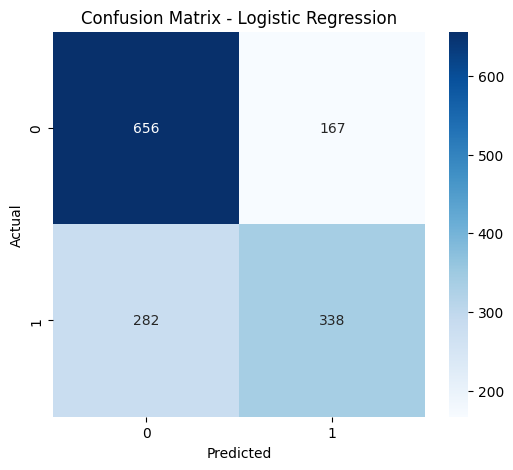

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

logistic_param_dist = {
    'C': np.logspace(-3, 3, 7),
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [3000, 4000, 5000]
}

model = LogisticRegression(random_state=42)

logreg_search = RandomizedSearchCV(model_3, logistic_param_dist, n_iter=40, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

logreg_search.fit(X_train, y_train)

best_logreg = logreg_search.best_estimator_

y_pred_lr = best_logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_lr)

print("Best Parameters:", logreg_search.best_params_)
print(f"Test Accuracy: {accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### GBDT

Best Gradient Boosting Parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.01}
Accuracy with Best Gradient Boosting Parameters: 0.6874566874566874
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74       823
           1       0.65      0.58      0.62       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.68      1443
weighted avg       0.68      0.69      0.68      1443

Confusion Matrix:
 [[630 193]
 [258 362]]


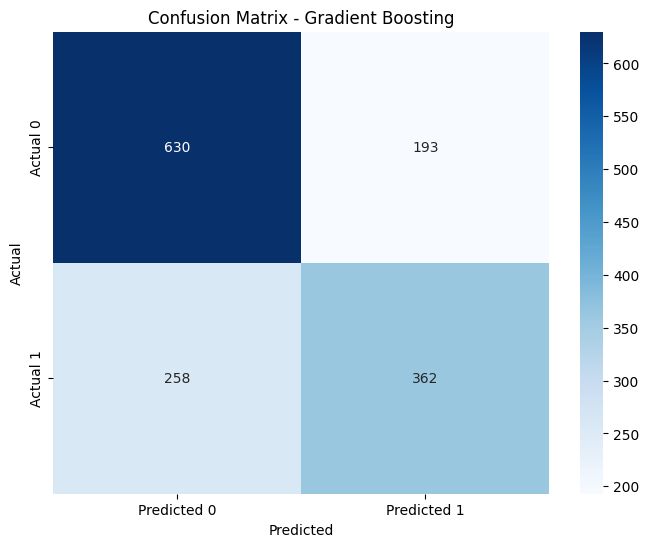

In [78]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

gbdt_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.8, 1.0]
}

gbdt_search = RandomizedSearchCV(model_4, gbdt_param_dist, n_iter=100, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

gbdt_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gbdt_search.best_params_)
best_gbdt = gbdt_search.best_estimator_

y_pred_gbdt = best_gbdt.predict(X_test)
accuracy_gbdt = accuracy_score(y_test, y_pred_gbdt)
print(f"Accuracy with Best Gradient Boosting Parameters: {accuracy_gbdt}")

class_report_gbdt = classification_report(y_test, y_pred_gbdt)
print("Classification Report:\n", class_report_gbdt)

conf_matrix_gbdt = confusion_matrix(y_test, y_pred_gbdt)
print("Confusion Matrix:\n", conf_matrix_gbdt)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gbdt, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### RFC

Best Parameters (RFC): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7}
Test Accuracy (RFC): 0.6826056826056826
Classification Report (RFC):
               precision    recall  f1-score   support

           0       0.70      0.77      0.73       823
           1       0.65      0.57      0.61       620

    accuracy                           0.68      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.68      0.68      0.68      1443



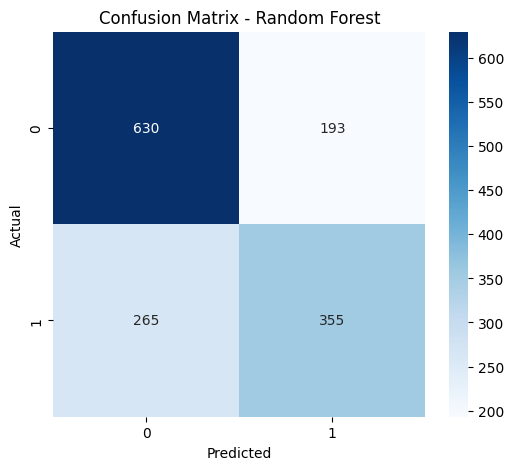

In [79]:
from sklearn.ensemble import RandomForestClassifier

rfc_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_model = RandomForestClassifier(random_state=42)

rfc_search = RandomizedSearchCV(
    rfc_model,
    param_distributions=rfc_param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rfc_search.fit(X_train, y_train)

best_rfc = rfc_search.best_estimator_
y_pred_rfc = best_rfc.predict(X_test)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)

print("Best Parameters (RFC):", rfc_search.best_params_)
print(f"Test Accuracy (RFC): {accuracy_rfc}")
print("Classification Report (RFC):\n", classification_report(y_test, y_pred_rfc))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### NN (MLPClassifier)

Best Parameters (NN): {'solver': 'adam', 'max_iter': 500, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'tanh'}
Test Accuracy (NN): 0.693000693000693
Classification Report (NN):
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.55      0.61       620

    accuracy                           0.69      1443
   macro avg       0.69      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443



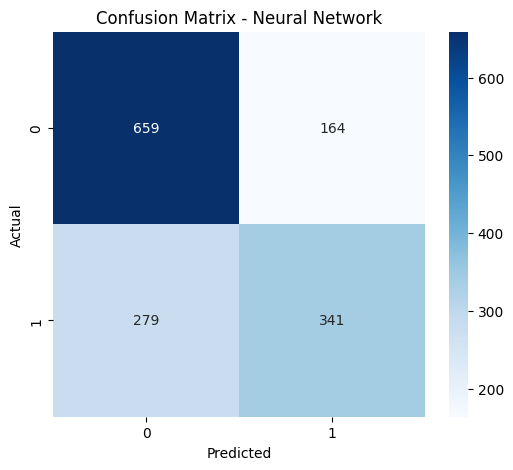

In [82]:
from sklearn.neural_network import MLPClassifier

nn_param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500, 1000, 1500]
}

nn_model = MLPClassifier(random_state=42)

nn_search = RandomizedSearchCV(
    nn_model,
    param_distributions=nn_param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

nn_search.fit(X_train, y_train)

best_nn = nn_search.best_estimator_
y_pred_nn = best_nn.predict(X_test)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print("Best Parameters (NN):", nn_search.best_params_)
print(f"Test Accuracy (NN): {accuracy_nn}")
print("Classification Report (NN):\n", classification_report(y_test, y_pred_nn))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network")
plt.show()


# SHAP

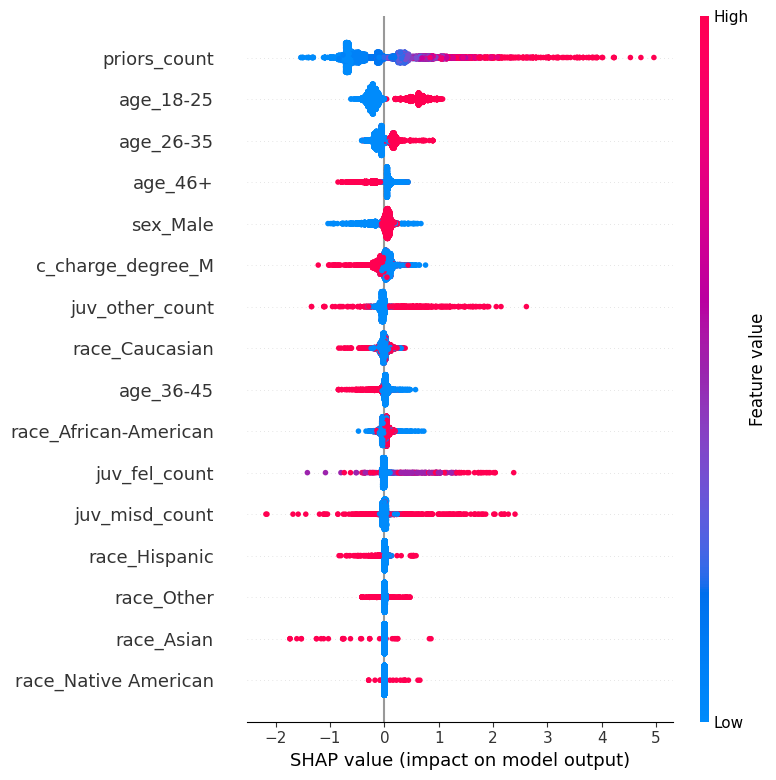

In [166]:
# Two year XGB
import shap

explainer = shap.TreeExplainer(model_1)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

  0%|          | 0/200 [00:00<?, ?it/s]

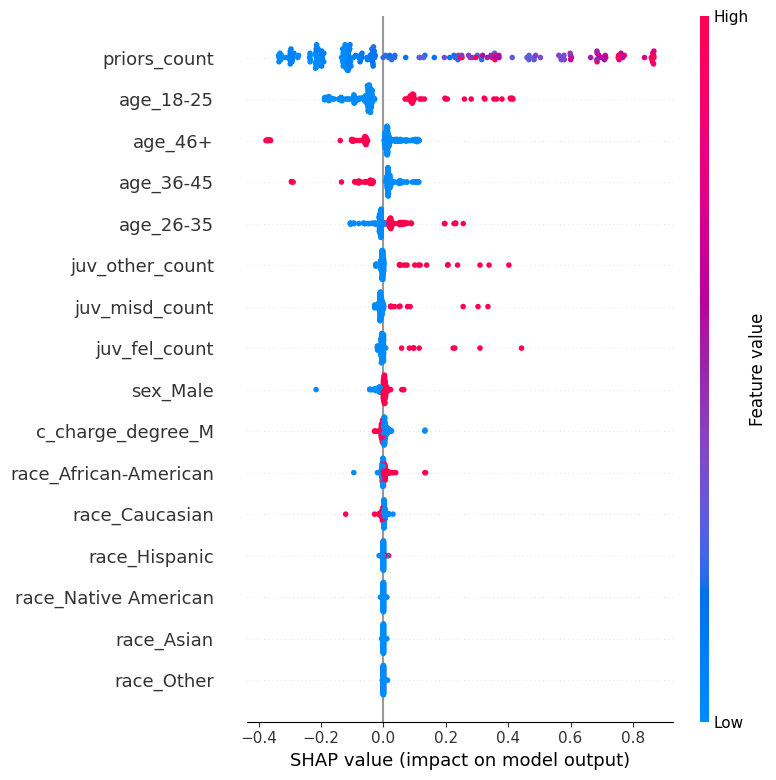

In [198]:
# Two year recid SVC
import shap

explainer = shap.KernelExplainer(model_2.predict, shap.sample(X_train, 100))
shap_values = explainer.shap_values(X[:200])

shap.summary_plot(shap_values, X[:200])

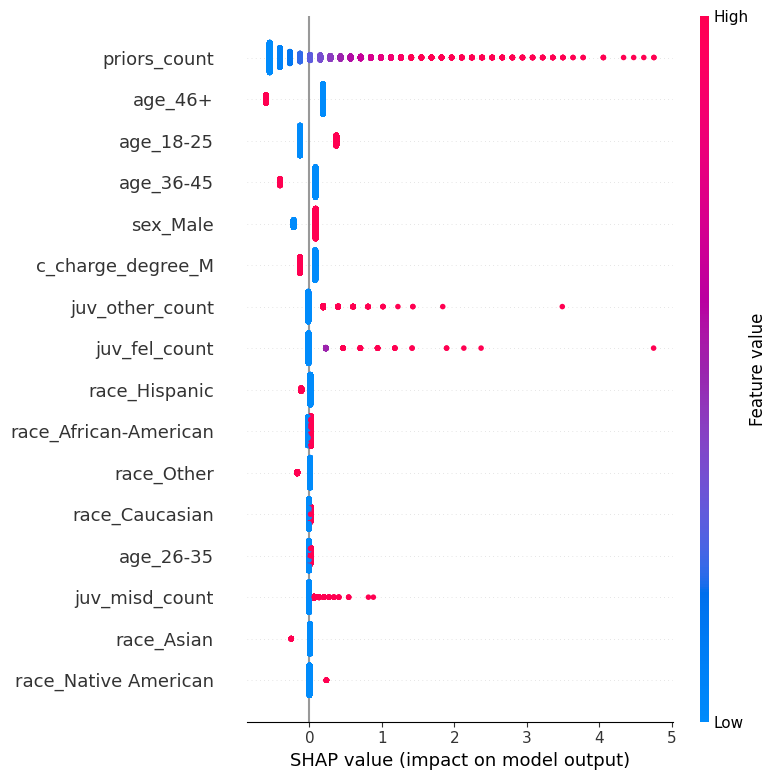

In [167]:
# Two year recid LogReg
import shap

explainer = shap.LinearExplainer(model_3, X_train)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

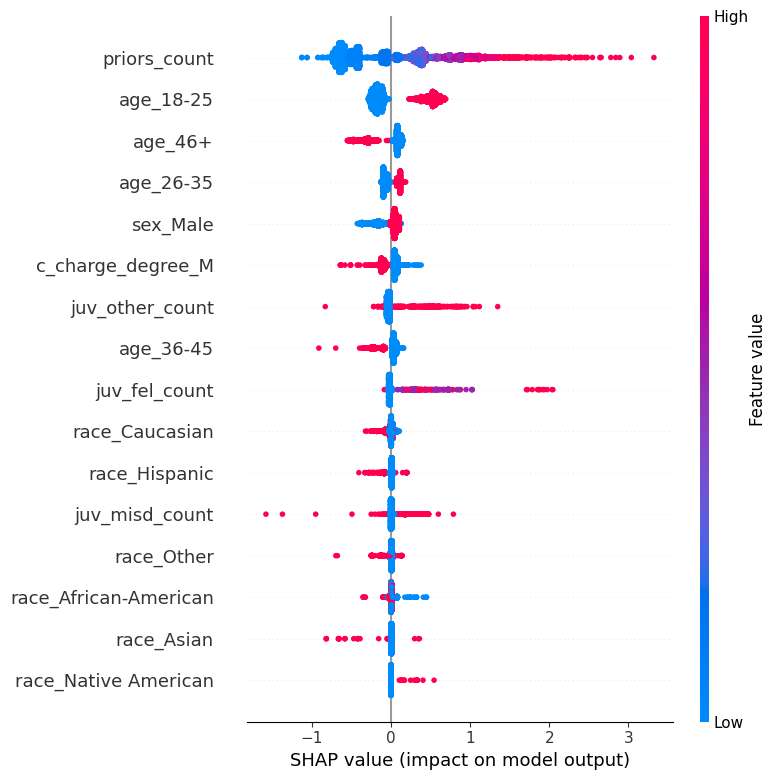

In [168]:
# Two year GBDT
import shap

explainer = shap.Explainer(model_4)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

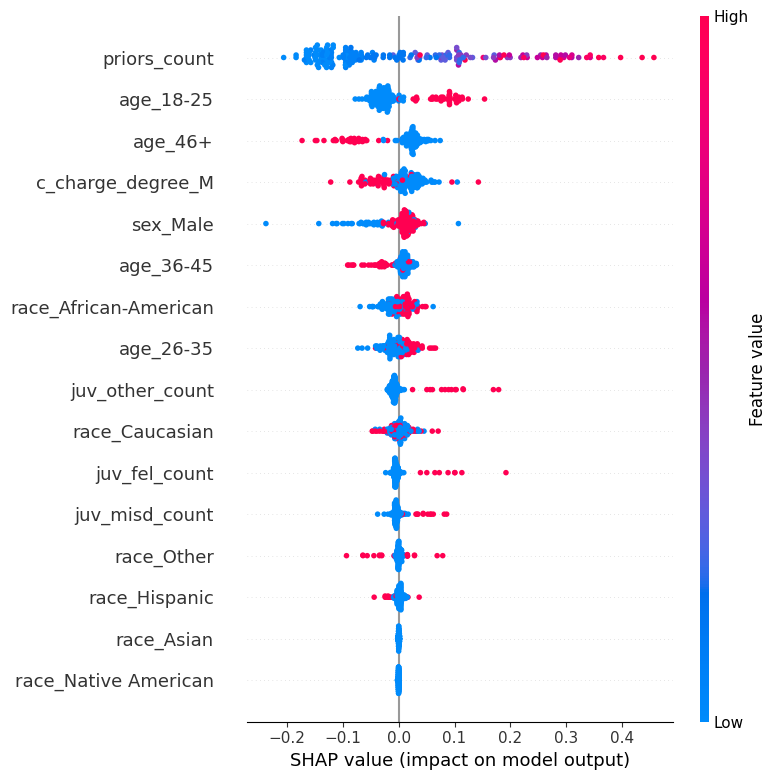

In [176]:
# Two year RFC
import shap

X_sample = X[:200]

explainer = shap.TreeExplainer(model_5)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values[1], X_sample)


  0%|          | 0/200 [00:00<?, ?it/s]

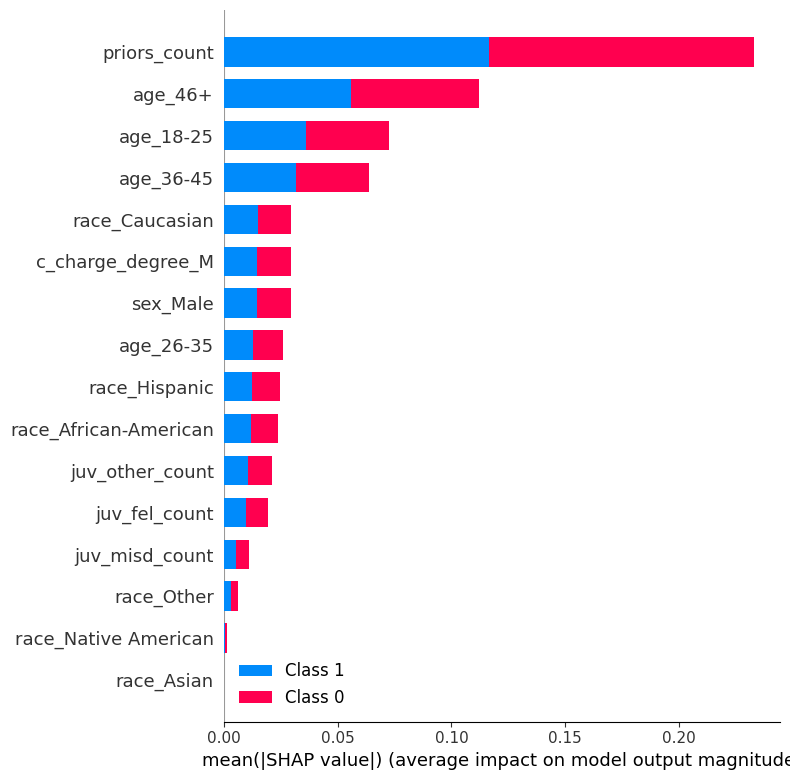

In [177]:
# Two year nn
import shap

X_sample = shap.sample(X, 200, random_state=42)

explainer = shap.KernelExplainer(model_6.predict_proba, X_sample)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

# Fairlearn

### Sex

In [88]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

sensitive_attr = X_test['sex_Male']

model_predictions = {
    "XGB": y_pred_xgb,
    "SVC": y_pred_svm,
    "LR": y_pred_lr,
    "GBDT": y_pred_gbdt,
    "RFC": y_pred_rfc,
    "NN": y_pred_nn
}

for model_name, y_pred in model_predictions.items():
    metrics = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_attr)
    print(f"{model_name} Overall Accuracy: {metrics.overall}")
    print(f"{model_name} Accuracy by Group:\n{metrics.by_group}\n")


XGB Overall Accuracy: 0.6888426888426888
XGB Accuracy by Group:
sex_Male
0    0.716000
1    0.683152
Name: accuracy_score, dtype: float64

SVC Overall Accuracy: 0.6909216909216909
SVC Accuracy by Group:
sex_Male
0    0.732000
1    0.682313
Name: accuracy_score, dtype: float64

LR Overall Accuracy: 0.6888426888426888
LR Accuracy by Group:
sex_Male
0    0.716000
1    0.683152
Name: accuracy_score, dtype: float64

GBDT Overall Accuracy: 0.6874566874566874
GBDT Accuracy by Group:
sex_Male
0    0.712000
1    0.682313
Name: accuracy_score, dtype: float64

RFC Overall Accuracy: 0.6826056826056826
RFC Accuracy by Group:
sex_Male
0    0.712000
1    0.676446
Name: accuracy_score, dtype: float64

NN Overall Accuracy: 0.693000693000693
NN Accuracy by Group:
sex_Male
0    0.728000
1    0.685666
Name: accuracy_score, dtype: float64



### Race

In [89]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

sensitive_attr = X_test['race_African-American']

model_predictions = {
    "XGB": y_pred_xgb,
    "SVC": y_pred_svm,
    "LR": y_pred_lr,
    "GBDT": y_pred_gbdt,
    "RFC": y_pred_rfc,
    "NN": y_pred_nn
}

for model_name, y_pred in model_predictions.items():
    metrics = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_attr)
    print(f"{model_name} Overall Accuracy: {metrics.overall}")
    print(f"{model_name} Accuracy by Group:\n{metrics.by_group}\n")


XGB Overall Accuracy: 0.6888426888426888
XGB Accuracy by Group:
race_African-American
0    0.685393
1    0.692202
Name: accuracy_score, dtype: float64

SVC Overall Accuracy: 0.6909216909216909
SVC Accuracy by Group:
race_African-American
0    0.692416
1    0.689466
Name: accuracy_score, dtype: float64

LR Overall Accuracy: 0.6888426888426888
LR Accuracy by Group:
race_African-American
0    0.692416
1    0.685363
Name: accuracy_score, dtype: float64

GBDT Overall Accuracy: 0.6874566874566874
GBDT Accuracy by Group:
race_African-American
0    0.686798
1    0.688098
Name: accuracy_score, dtype: float64

RFC Overall Accuracy: 0.6826056826056826
RFC Accuracy by Group:
race_African-American
0    0.681180
1    0.683995
Name: accuracy_score, dtype: float64

NN Overall Accuracy: 0.693000693000693
NN Accuracy by Group:
race_African-American
0    0.693820
1    0.692202
Name: accuracy_score, dtype: float64



# LIME (Only useful for explaining individual row predictions)

In [90]:
import lime
import lime.lime_tabular

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    mode='classification'
)

# Explain an instance (e.g., first row)
exp = explainer.explain_instance(X.iloc[0].values, model_1.predict_proba)
exp.show_in_notebook()

# In processing and post processing

In [179]:
!pip install scikit-posthocs aif360 xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 6.5 MB/s eta 0:00:00:00:01


In [180]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from aif360.metrics import ClassificationMetric
from aif360.algorithms.postprocessing import RejectOptionClassification, CalibratedEqOddsPostprocessing, EqOddsPostprocessing
from aif360.algorithms.inprocessing import AdversarialDebiasing
import tensorflow as tf
from aif360.datasets import BinaryLabelDataset
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

2025-09-30 17:05:50.380958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759251950.762328      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759251950.864951      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## For sex


### XGB

In [181]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'sex_Male': 1}]
unprivileged_groups = [{'sex_Male': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(df=df_train, label_names=['label'], protected_attribute_names=['sex_Male'])

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(df=df_test, label_names=['label'], protected_attribute_names=['sex_Male'])

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        subsample=0.6,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        colsample_bytree=0.8
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['label'], protected_attribute_names=['sex_Male'])

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

I0000 00:00:1759251967.465292      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759251967.466121      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1759251967.972093      36 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


epoch 0; iter: 0; batch classifier loss: 0.823173; batch adversarial loss: 0.613001
epoch 1; iter: 0; batch classifier loss: 0.703035; batch adversarial loss: 0.631608
epoch 2; iter: 0; batch classifier loss: 0.656598; batch adversarial loss: 0.638471
epoch 3; iter: 0; batch classifier loss: 0.660440; batch adversarial loss: 0.683377
epoch 4; iter: 0; batch classifier loss: 0.797673; batch adversarial loss: 0.747999
epoch 5; iter: 0; batch classifier loss: 0.796417; batch adversarial loss: 0.692144
epoch 6; iter: 0; batch classifier loss: 0.886568; batch adversarial loss: 0.682998
epoch 7; iter: 0; batch classifier loss: 0.767500; batch adversarial loss: 0.662547
epoch 8; iter: 0; batch classifier loss: 0.913591; batch adversarial loss: 0.634068
epoch 9; iter: 0; batch classifier loss: 0.918506; batch adversarial loss: 0.668182
epoch 10; iter: 0; batch classifier loss: 0.902113; batch adversarial loss: 0.572777
epoch 11; iter: 0; batch classifier loss: 0.789899; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759251989.318808      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759251989.319165      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.776229; batch adversarial loss: 0.617883
epoch 1; iter: 0; batch classifier loss: 0.602634; batch adversarial loss: 0.623321
epoch 2; iter: 0; batch classifier loss: 0.579345; batch adversarial loss: 0.565949
epoch 3; iter: 0; batch classifier loss: 0.646014; batch adversarial loss: 0.548091
epoch 4; iter: 0; batch classifier loss: 0.646233; batch adversarial loss: 0.579445
epoch 5; iter: 0; batch classifier loss: 0.621735; batch adversarial loss: 0.593794
epoch 6; iter: 0; batch classifier loss: 0.602865; batch adversarial loss: 0.584379
epoch 7; iter: 0; batch classifier loss: 0.648273; batch adversarial loss: 0.573200
epoch 8; iter: 0; batch classifier loss: 0.654313; batch adversarial loss: 0.575124
epoch 9; iter: 0; batch classifier loss: 0.650520; batch adversarial loss: 0.555686
epoch 10; iter: 0; batch classifier loss: 0.614976; batch adversarial loss: 0.559709
epoch 11; iter: 0; batch classifier loss: 0.603179; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252010.167639      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252010.167985      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

Unable to satisy fairness constraints
I0000 00:00:1759252052.190055      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252052.190367      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.712625; batch adversarial loss: 0.625027
epoch 1; iter: 0; batch classifier loss: 0.633068; batch adversarial loss: 0.637961
epoch 2; iter: 0; batch classifier loss: 0.680087; batch adversarial loss: 0.634188
epoch 3; iter: 0; batch classifier loss: 0.628492; batch adversarial loss: 0.640953
epoch 4; iter: 0; batch classifier loss: 0.704426; batch adversarial loss: 0.653577
epoch 5; iter: 0; batch classifier loss: 0.756444; batch adversarial loss: 0.668844
epoch 6; iter: 0; batch classifier loss: 0.865812; batch adversarial loss: 0.626020
epoch 7; iter: 0; batch classifier loss: 0.789122; batch adversarial loss: 0.622701
epoch 8; iter: 0; batch classifier loss: 0.818794; batch adversarial loss: 0.640131
epoch 9; iter: 0; batch classifier loss: 0.751778; batch adversarial loss: 0.611602
epoch 10; iter: 0; batch classifier loss: 0.715262; batch adversarial loss: 0.589487
epoch 11; iter: 0; batch classifier loss: 0.761300; batch adversarial loss:

Unable to satisy fairness constraints
divide by zero encountered in scalar divide



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=19.70873786407768, pvalue=0.006234384605809909)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=24.474698795180725, pvalue=0.0009398245688073485)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=24.33975903614459, pvalue=0.0009927717936445053)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=24.474698795180725, pvalue=0.0009398245688073485)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.934829  0.002392  0.223503  0.838027
2  0.934829  1.000000  0.041143  0.702853  0.999154
3  0.002392  0.041143  1.000000  0.588302  0.083894
4  0.223503  0.702853  0.588302  1.000000  0.842483
5  0.838027  0.999154  0.083894  0.842483  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.967353  0.983704  1.000000  0.908171
2  0.967353  1.000000  0.999966  0.960090  0.545115
3  0

invalid value encountered in subtract


### SVC

In [182]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'sex_Male': 1}]
unprivileged_groups = [{'sex_Male': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(df=df_train, label_names=['label'], protected_attribute_names=['sex_Male'])

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(df=df_test, label_names=['label'], protected_attribute_names=['sex_Male'])

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = SVC(kernel='rbf', gamma=0.01, C=50, probability=True, random_state=42)

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['label'], protected_attribute_names=['sex_Male'])

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

I0000 00:00:1759252084.897633      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252084.897920      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252115.052510      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252115.052778      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252146.631424      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252146.631742      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

Unable to satisy fairness constraints
I0000 00:00:1759252209.235716      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252209.235969      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.712625; batch adversarial loss: 0.625027
epoch 1; iter: 0; batch classifier loss: 0.633068; batch adversarial loss: 0.637961
epoch 2; iter: 0; batch classifier loss: 0.680087; batch adversarial loss: 0.634188
epoch 3; iter: 0; batch classifier loss: 0.628492; batch adversarial loss: 0.640953
epoch 4; iter: 0; batch classifier loss: 0.704426; batch adversarial loss: 0.653577
epoch 5; iter: 0; batch classifier loss: 0.756444; batch adversarial loss: 0.668844
epoch 6; iter: 0; batch classifier loss: 0.865812; batch adversarial loss: 0.626020
epoch 7; iter: 0; batch classifier loss: 0.789122; batch adversarial loss: 0.622701
epoch 8; iter: 0; batch classifier loss: 0.818794; batch adversarial loss: 0.640131
epoch 9; iter: 0; batch classifier loss: 0.751778; batch adversarial loss: 0.611602
epoch 10; iter: 0; batch classifier loss: 0.715262; batch adversarial loss: 0.589487
epoch 11; iter: 0; batch classifier loss: 0.761300; batch adversarial loss:

Unable to satisy fairness constraints
divide by zero encountered in scalar divide



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=19.56585365853658, pvalue=0.0065878700683222255)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=26.63373493975903, pvalue=0.0003878330206568422)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=24.879518072289166, pvalue=0.0007970309691090295)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=26.498795180722894, pvalue=0.0004100685230784266)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.994291  0.002033  0.194840  0.679088
2  0.994291  1.000000  0.010166  0.411170  0.894292
3  0.002033  0.010166  1.000000  0.606414  0.152212
4  0.194840  0.411170  0.606414  1.000000  0.926438
5  0.679088  0.894292  0.152212  0.926438  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.999894  0.981501  0.999272  0.810109
2  0.999894  1.000000  0.956088  0.999984  0.879736
3  

invalid value encountered in subtract


### Logistic Regression

In [183]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'sex_Male': 1}]
unprivileged_groups = [{'sex_Male': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(df=df_train, label_names=['label'], protected_attribute_names=['sex_Male'])

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(df=df_test, label_names=['label'], protected_attribute_names=['sex_Male'])

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=0.01,
        max_iter=5000,
        random_state=42
    )


    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['label'], protected_attribute_names=['sex_Male'])

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

I0000 00:00:1759252230.540967      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252230.541358      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252251.890560      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252251.890912      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252273.753096      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252273.753391      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

Unable to satisy fairness constraints
I0000 00:00:1759252314.824463      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252314.824753      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.712625; batch adversarial loss: 0.625027
epoch 1; iter: 0; batch classifier loss: 0.633068; batch adversarial loss: 0.637961
epoch 2; iter: 0; batch classifier loss: 0.680087; batch adversarial loss: 0.634188
epoch 3; iter: 0; batch classifier loss: 0.628492; batch adversarial loss: 0.640953
epoch 4; iter: 0; batch classifier loss: 0.704426; batch adversarial loss: 0.653577
epoch 5; iter: 0; batch classifier loss: 0.756444; batch adversarial loss: 0.668844
epoch 6; iter: 0; batch classifier loss: 0.865812; batch adversarial loss: 0.626020
epoch 7; iter: 0; batch classifier loss: 0.789122; batch adversarial loss: 0.622701
epoch 8; iter: 0; batch classifier loss: 0.818794; batch adversarial loss: 0.640131
epoch 9; iter: 0; batch classifier loss: 0.751778; batch adversarial loss: 0.611602
epoch 10; iter: 0; batch classifier loss: 0.715262; batch adversarial loss: 0.589487
epoch 11; iter: 0; batch classifier loss: 0.761300; batch adversarial loss:

Unable to satisy fairness constraints
divide by zero encountered in scalar divide



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=24.576642335766437, pvalue=0.0009016672309926868)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=26.63373493975903, pvalue=0.0003878330206568422)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=24.204819277108424, pvalue=0.001048634952646736)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=26.498795180722894, pvalue=0.0004100685230784266)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.992028  0.029867  0.218958  0.879516
2  0.992028  1.000000  0.106433  0.470750  0.987521
3  0.029867  0.106433  1.000000  0.942427  0.312213
4  0.218958  0.470750  0.942427  1.000000  0.789919
5  0.879516  0.987521  0.312213  0.789919  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.999742  0.967353  0.999998  0.819687
2  0.999742  1.000000  0.920728  0.999272  0.901476
3  

invalid value encountered in subtract


### GBDT

In [184]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'sex_Male': 1}]
unprivileged_groups = [{'sex_Male': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(df=df_train, label_names=['label'], protected_attribute_names=['sex_Male'])

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(df=df_test, label_names=['label'], protected_attribute_names=['sex_Male'])

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = GradientBoostingClassifier(
        subsample=0.6,
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=4,
        max_depth=4,
        learning_rate=0.01,
        random_state=42
    )


    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['label'], protected_attribute_names=['sex_Male'])

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

I0000 00:00:1759252336.745573      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252336.745809      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252358.355255      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252358.355531      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252378.190311      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252378.190578      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

Unable to satisy fairness constraints
I0000 00:00:1759252419.837295      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252419.837570      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.712625; batch adversarial loss: 0.625027
epoch 1; iter: 0; batch classifier loss: 0.633068; batch adversarial loss: 0.637961
epoch 2; iter: 0; batch classifier loss: 0.680087; batch adversarial loss: 0.634188
epoch 3; iter: 0; batch classifier loss: 0.628492; batch adversarial loss: 0.640953
epoch 4; iter: 0; batch classifier loss: 0.704426; batch adversarial loss: 0.653577
epoch 5; iter: 0; batch classifier loss: 0.756444; batch adversarial loss: 0.668844
epoch 6; iter: 0; batch classifier loss: 0.865812; batch adversarial loss: 0.626020
epoch 7; iter: 0; batch classifier loss: 0.789122; batch adversarial loss: 0.622701
epoch 8; iter: 0; batch classifier loss: 0.818794; batch adversarial loss: 0.640131
epoch 9; iter: 0; batch classifier loss: 0.751778; batch adversarial loss: 0.611602
epoch 10; iter: 0; batch classifier loss: 0.715262; batch adversarial loss: 0.589487
epoch 11; iter: 0; batch classifier loss: 0.761300; batch adversarial loss:

Unable to satisy fairness constraints
divide by zero encountered in scalar divide



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=18.016949152542377, pvalue=0.01189376475984668)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=25.959036144578317, pvalue=0.0005122275510490276)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=24.407228915662657, pvalue=0.0009659431379186749)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=26.63373493975903, pvalue=0.0003878330206568422)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.887171  0.001890  0.292364  0.985703
2  0.887171  1.000000  0.052695  0.855446  0.994299
3  0.001890  0.052695  1.000000  0.459008  0.014226
4  0.292364  0.855446  0.459008  1.000000  0.619059
5  0.985703  0.994299  0.014226  0.619059  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  1.000000  0.997908  1.000000  0.863880
2  1.000000  1.000000  0.996772  1.000000  0.879736
3  0

invalid value encountered in subtract


### RFC

In [185]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'sex_Male': 1}]
unprivileged_groups = [{'sex_Male': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(df=df_train, label_names=['label'], protected_attribute_names=['sex_Male'])

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(df=df_test, label_names=['label'], protected_attribute_names=['sex_Male'])

    # ----------------------------
    # Initial Model
    # ----------------------------

    clf = RandomForestClassifier(
        n_estimators=100,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='log2',
        max_depth=7,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['label'], protected_attribute_names=['sex_Male'])

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

I0000 00:00:1759252442.844594      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252442.844913      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252463.756955      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252463.757294      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252484.665802      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252484.666080      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

Unable to satisy fairness constraints
I0000 00:00:1759252526.163104      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252526.163348      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.712625; batch adversarial loss: 0.625027
epoch 1; iter: 0; batch classifier loss: 0.633068; batch adversarial loss: 0.637961
epoch 2; iter: 0; batch classifier loss: 0.680087; batch adversarial loss: 0.634188
epoch 3; iter: 0; batch classifier loss: 0.628492; batch adversarial loss: 0.640953
epoch 4; iter: 0; batch classifier loss: 0.704426; batch adversarial loss: 0.653577
epoch 5; iter: 0; batch classifier loss: 0.756444; batch adversarial loss: 0.668844
epoch 6; iter: 0; batch classifier loss: 0.865812; batch adversarial loss: 0.626020
epoch 7; iter: 0; batch classifier loss: 0.789122; batch adversarial loss: 0.622701
epoch 8; iter: 0; batch classifier loss: 0.818794; batch adversarial loss: 0.640131
epoch 9; iter: 0; batch classifier loss: 0.751778; batch adversarial loss: 0.611602
epoch 10; iter: 0; batch classifier loss: 0.715262; batch adversarial loss: 0.589487
epoch 11; iter: 0; batch classifier loss: 0.761300; batch adversarial loss:

Unable to satisy fairness constraints
divide by zero encountered in scalar divide



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=14.136585365853671, pvalue=0.04880469742081064)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=27.252427184466008, pvalue=0.00030014909866979395)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=24.33009708737865, pvalue=0.000996672978017946)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=27.048543689320386, pvalue=0.000326641082338976)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.942493  0.000769  0.139892  0.871846
2  0.942493  1.000000  0.016187  0.544877  0.999624
3  0.000769  0.016187  1.000000  0.557278  0.031769
4  0.139892  0.544877  0.557278  1.000000  0.679404
5  0.871846  0.999624  0.031769  0.679404  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.999998  0.993239  0.999966  0.691250
2  0.999998  1.000000  0.996058  0.999830  0.655614
3  0.

invalid value encountered in subtract


### NN (MLPClassifier)

In [186]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'sex_Male': 1}]
unprivileged_groups = [{'sex_Male': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(df=df_train, label_names=['label'], protected_attribute_names=['sex_Male'])

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(df=df_test, label_names=['label'], protected_attribute_names=['sex_Male'])

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = MLPClassifier(
        solver='adam',
        max_iter=500,
        learning_rate='adaptive',
        hidden_layer_sizes=(100,),
        alpha=0.001,
        activation='tanh',
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['label'], protected_attribute_names=['sex_Male'])

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

I0000 00:00:1759252551.996801      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252551.997157      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252574.420465      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252574.420828      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252600.133449      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252600.133743      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

Unable to satisy fairness constraints
I0000 00:00:1759252648.264081      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252648.264412      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.712625; batch adversarial loss: 0.625027
epoch 1; iter: 0; batch classifier loss: 0.633068; batch adversarial loss: 0.637961
epoch 2; iter: 0; batch classifier loss: 0.680087; batch adversarial loss: 0.634188
epoch 3; iter: 0; batch classifier loss: 0.628492; batch adversarial loss: 0.640953
epoch 4; iter: 0; batch classifier loss: 0.704426; batch adversarial loss: 0.653577
epoch 5; iter: 0; batch classifier loss: 0.756444; batch adversarial loss: 0.668844
epoch 6; iter: 0; batch classifier loss: 0.865812; batch adversarial loss: 0.626020
epoch 7; iter: 0; batch classifier loss: 0.789122; batch adversarial loss: 0.622701
epoch 8; iter: 0; batch classifier loss: 0.818794; batch adversarial loss: 0.640131
epoch 9; iter: 0; batch classifier loss: 0.751778; batch adversarial loss: 0.611602
epoch 10; iter: 0; batch classifier loss: 0.715262; batch adversarial loss: 0.589487
epoch 11; iter: 0; batch classifier loss: 0.761300; batch adversarial loss:

Unable to satisy fairness constraints
divide by zero encountered in scalar divide



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=23.895377128953765, pvalue=0.001188607285584246)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=26.63373493975903, pvalue=0.0003878330206568422)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=24.60963855421686, pvalue=0.0008896449076947001)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=26.498795180722894, pvalue=0.0004100685230784266)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.989193  0.003768  0.227615  0.855403
2  0.989193  1.000000  0.022140  0.507691  0.985698
3  0.003768  0.022140  1.000000  0.655449  0.101687
4  0.227615  0.507691  0.655449  1.000000  0.828854
5  0.855403  0.985698  0.101687  0.828854  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.999993  0.993242  0.998351  0.714502
2  0.999993  1.000000  0.987547  0.999469  0.758910
3  0

invalid value encountered in subtract


## For race

### XGB

In [187]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'race_African-American': 1}]
unprivileged_groups = [{'race_African-American': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(
        df=df_train, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(
        df=df_test, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        subsample=0.6,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        colsample_bytree=0.8
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(
        df=df_pred, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")


I0000 00:00:1759252670.826907      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252670.827139      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.870045
epoch 1; iter: 0; batch classifier loss: 0.673744; batch adversarial loss: 0.841353
epoch 2; iter: 0; batch classifier loss: 0.613463; batch adversarial loss: 0.770119
epoch 3; iter: 0; batch classifier loss: 0.658448; batch adversarial loss: 0.785224
epoch 4; iter: 0; batch classifier loss: 0.666974; batch adversarial loss: 0.798268
epoch 5; iter: 0; batch classifier loss: 0.675900; batch adversarial loss: 0.779031
epoch 6; iter: 0; batch classifier loss: 0.669967; batch adversarial loss: 0.738363
epoch 7; iter: 0; batch classifier loss: 0.643794; batch adversarial loss: 0.756376
epoch 8; iter: 0; batch classifier loss: 0.619154; batch adversarial loss: 0.716931
epoch 9; iter: 0; batch classifier loss: 0.635924; batch adversarial loss: 0.705961
epoch 10; iter: 0; batch classifier loss: 0.648993; batch adversarial loss: 0.723875
epoch 11; iter: 0; batch classifier loss: 0.604652; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252692.008642      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252692.008964      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.845915; batch adversarial loss: 0.696405
epoch 1; iter: 0; batch classifier loss: 0.639843; batch adversarial loss: 0.691665
epoch 2; iter: 0; batch classifier loss: 0.697440; batch adversarial loss: 0.692579
epoch 3; iter: 0; batch classifier loss: 0.615203; batch adversarial loss: 0.684638
epoch 4; iter: 0; batch classifier loss: 0.639591; batch adversarial loss: 0.693071
epoch 5; iter: 0; batch classifier loss: 0.620847; batch adversarial loss: 0.677368
epoch 6; iter: 0; batch classifier loss: 0.634382; batch adversarial loss: 0.696320
epoch 7; iter: 0; batch classifier loss: 0.603117; batch adversarial loss: 0.700020
epoch 8; iter: 0; batch classifier loss: 0.632978; batch adversarial loss: 0.691058
epoch 9; iter: 0; batch classifier loss: 0.619485; batch adversarial loss: 0.691023
epoch 10; iter: 0; batch classifier loss: 0.616602; batch adversarial loss: 0.692556
epoch 11; iter: 0; batch classifier loss: 0.639204; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252715.578976      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252715.579241      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759252758.308783      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759252758.309174      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

Unable to satisy fairness constraints



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=30.748780487804865, pvalue=6.916871999136401e-05)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=28.475728155339812, pvalue=0.00018024975237068046)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=29.834951456310666, pvalue=0.00010181191934055712)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=31.26213592233009, pvalue=5.561967783505866e-05)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.322724  0.015645  0.004528  0.106523
2  0.322724  1.000000  0.774541  0.563291  0.985693
3  0.015645  0.774541  1.000000  0.997381  0.968971
4  0.004528  0.563291  0.997381  1.000000  0.867766
5  0.106523  0.985693  0.968971  0.867766  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.999966  0.999938  0.998719  0.908128
2  0.999966  1.000000  1.000000  0.999830  0.942512


### SVC

In [193]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'race_African-American': 1}]
unprivileged_groups = [{'race_African-American': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(
        df=df_train, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(
        df=df_test, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = SVC(kernel='rbf', gamma=0.01, C=50, probability=True, random_state=42)

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(
        df=df_pred, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")


I0000 00:00:1759253400.163296      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253400.163612      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253430.548428      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253430.548740      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253461.368482      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253461.368804      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253528.004404      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253528.004722      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

Unable to satisy fairness constraints



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=29.467469879518077, pvalue=0.00011886870080460978)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=30.681927710843368, pvalue=7.11574994909264e-05)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=30.007228915662655, pvalue=9.467024147874528e-05)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=30.546987951807232, pvalue=7.534530883518649e-05)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.790239  0.046044  0.017844  0.146245
2  0.790239  1.000000  0.514146  0.328369  0.790239
3  0.046044  0.514146  1.000000  0.998350  0.992660
4  0.017844  0.328369  0.998350  1.000000  0.949600
5  0.146245  0.790239  0.992660  0.949600  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.970627  0.932180  0.999966  0.999624
2  0.970627  1.000000  0.999830  0.947318  0.920728
3

### Logistic Regression

In [194]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'race_African-American': 1}]
unprivileged_groups = [{'race_African-American': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(
        df=df_train, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(
        df=df_test, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=0.01,
        max_iter=5000,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(
        df=df_pred, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")


I0000 00:00:1759253650.419782      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253650.420180      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253671.520227      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253671.520594      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253692.715322      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253692.715609      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253734.291819      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253734.292180      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

Unable to satisy fairness constraints



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=31.491566265060246, pvalue=5.044644222348228e-05)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=30.277108433734927, pvalue=8.44640948005423e-05)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=31.626506024096383, pvalue=4.762891610974643e-05)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=30.546987951807232, pvalue=7.534530883518649e-05)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.655614  0.055640  0.007769  0.152581
2  0.655614  1.000000  0.702890  0.323022  0.901430
3  0.055640  0.702890  1.000000  0.976481  0.995238
4  0.007769  0.323022  0.976481  1.000000  0.863819
5  0.152581  0.901430  0.995238  0.863819  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.987547  0.947318  0.999966  0.998351
2  0.987547  1.000000  0.999272  0.973671  0.932180
3 

### GBDT

In [195]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'race_African-American': 1}]
unprivileged_groups = [{'race_African-American': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(
        df=df_train, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(
        df=df_test, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = GradientBoostingClassifier(
        subsample=0.6,
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=4,
        max_depth=4,
        learning_rate=0.01,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(
        df=df_pred, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")


I0000 00:00:1759253757.770644      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253757.770952      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253779.298621      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253779.298971      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253801.247284      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253801.247589      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253844.785254      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253844.785549      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

Unable to satisy fairness constraints



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=27.763285024154595, pvalue=0.00024270040065969028)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=30.681927710843368, pvalue=7.11574994909264e-05)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=30.378640776699044, pvalue=8.091231626253656e-05)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=30.546987951807232, pvalue=7.534530883518649e-05)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.417259  0.017785  0.006272  0.165803
2  0.417259  1.000000  0.702703  0.513804  0.988381
3  0.017785  0.702703  1.000000  0.998542  0.934787
4  0.006272  0.513804  0.998542  1.000000  0.819481
5  0.165803  0.988381  0.934787  0.819481  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.894505  0.871942  0.999894  0.999966
2  0.894505  1.000000  0.999998  0.942541  0.932180
3

### RFC

In [196]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'race_African-American': 1}]
unprivileged_groups = [{'race_African-American': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(
        df=df_train, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(
        df=df_test, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = RandomForestClassifier(
        n_estimators=100,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='log2',
        max_depth=7,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(
        df=df_pred, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")


I0000 00:00:1759253866.754904      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253866.755227      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253888.011505      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253888.011889      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253909.163090      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253909.163391      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759253957.126657      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253957.127011      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

Unable to satisy fairness constraints



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=27.713253012048185, pvalue=0.0002478111436506526)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=30.412048192771096, pvalue=7.977621342512338e-05)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=29.766990291262125, pvalue=0.00010477314352567348)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=30.546987951807232, pvalue=7.534530883518649e-05)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.452892  0.014681  0.009530  0.236255
2  0.452892  1.000000  0.631203  0.550981  0.995659
3  0.014681  0.631203  1.000000  0.999954  0.851138
4  0.009530  0.550981  0.999954  1.000000  0.790065
5  0.236255  0.995659  0.851138  0.790065  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.829026  0.703002  0.994304  0.999469
2  0.829026  1.000000  0.999469  0.967353  0.920728


### NN (MLPClassifier)

In [197]:
tf.compat.v1.disable_eager_execution()

# ----------------------------
# Metrics Function
# ----------------------------
def compute_metrics(dataset_true, dataset_pred, privileged_groups, unprivileged_groups):
    metric = ClassificationMetric(dataset_true, dataset_pred, privileged_groups, unprivileged_groups)
    accuracy = accuracy_score(dataset_true.labels, dataset_pred.labels)
    di = metric.disparate_impact()
    eod = metric.equal_opportunity_difference()
    fpr_diff = metric.false_positive_rate_difference()
    return accuracy, di, eod, fpr_diff

# ----------------------------
# Cross-validation setup
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics across folds
results = {
    "Initial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "Adversarial": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "ROC+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "CEO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []},
    "EO+Adv": {"accuracy": [], "di": [], "eod": [], "fpr_diff": []}
}

privileged_groups = [{'race_African-American': 1}]
unprivileged_groups = [{'race_African-American': 0}]

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Prepare datasets for AIF360
    df_train = X_train.copy()
    df_train['label'] = y_train
    dataset_train = BinaryLabelDataset(
        df=df_train, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    df_test = X_test.copy()
    df_test['label'] = y_test
    dataset_test = BinaryLabelDataset(
        df=df_test, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    # ----------------------------
    # Initial Model
    # ----------------------------
    clf = MLPClassifier(
        solver='adam',
        max_iter=500,
        learning_rate='adaptive',
        hidden_layer_sizes=(100,),
        alpha=0.001,
        activation='tanh',
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df_pred = X_test.copy()
    df_pred['label'] = y_pred
    dataset_pred = BinaryLabelDataset(
        df=df_pred, label_names=['label'], protected_attribute_names=['race_African-American']
    )

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred, privileged_groups, unprivileged_groups)
    results["Initial"]["accuracy"].append(acc)
    results["Initial"]["di"].append(di)
    results["Initial"]["eod"].append(eod)
    results["Initial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Adversarial Debiasing
    # ----------------------------
    tf.compat.v1.reset_default_graph()
    sess = tf.compat.v1.Session()
    adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name="adv", debias=True, sess=sess)
    adv.fit(dataset_train)
    dataset_adv_pred = adv.predict(dataset_test)

    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred, privileged_groups, unprivileged_groups)
    results["Adversarial"]["accuracy"].append(acc)
    results["Adversarial"]["di"].append(di)
    results["Adversarial"]["eod"].append(eod)
    results["Adversarial"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing (ROC, CEO, EO)
    # ----------------------------
    roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
    roc.fit(dataset_test, dataset_pred)
    dataset_roc = roc.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc, privileged_groups, unprivileged_groups)
    results["ROC"]["accuracy"].append(acc)
    results["ROC"]["di"].append(di)
    results["ROC"]["eod"].append(eod)
    results["ROC"]["fpr_diff"].append(fpr_diff)

    ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
    ceo.fit(dataset_test, dataset_pred)
    dataset_ceo = ceo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo, privileged_groups, unprivileged_groups)
    results["CEO"]["accuracy"].append(acc)
    results["CEO"]["di"].append(di)
    results["CEO"]["eod"].append(eod)
    results["CEO"]["fpr_diff"].append(fpr_diff)

    eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)
    eo.fit(dataset_test, dataset_pred)
    dataset_eo = eo.predict(dataset_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo, privileged_groups, unprivileged_groups)
    results["EO"]["accuracy"].append(acc)
    results["EO"]["di"].append(di)
    results["EO"]["eod"].append(eod)
    results["EO"]["fpr_diff"].append(fpr_diff)

    # ----------------------------
    # Post-processing on Adversarial
    # ----------------------------
    roc.fit(dataset_test, dataset_adv_pred)
    dataset_roc_adv = roc.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_roc_adv, privileged_groups, unprivileged_groups)
    results["ROC+Adv"]["accuracy"].append(acc)
    results["ROC+Adv"]["di"].append(di)
    results["ROC+Adv"]["eod"].append(eod)
    results["ROC+Adv"]["fpr_diff"].append(fpr_diff)

    ceo.fit(dataset_test, dataset_adv_pred)
    dataset_ceo_adv = ceo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_ceo_adv, privileged_groups, unprivileged_groups)
    results["CEO+Adv"]["accuracy"].append(acc)
    results["CEO+Adv"]["di"].append(di)
    results["CEO+Adv"]["eod"].append(eod)
    results["CEO+Adv"]["fpr_diff"].append(fpr_diff)

    eo.fit(dataset_test, dataset_adv_pred)
    dataset_eo_adv = eo.predict(dataset_adv_pred)
    acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_eo_adv, privileged_groups, unprivileged_groups)
    results["EO+Adv"]["accuracy"].append(acc)
    results["EO+Adv"]["di"].append(di)
    results["EO+Adv"]["eod"].append(eod)
    results["EO+Adv"]["fpr_diff"].append(fpr_diff)

    sess.close()

# ----------------------------
# Friedman test across methods
# ----------------------------
acc_matrix = np.array([results[m]["accuracy"] for m in results])
di_matrix = np.array([results[m]["di"] for m in results])
eod_matrix = np.array([results[m]["eod"] for m in results])
fpr_diff_matrix = np.array([results[m]["fpr_diff"] for m in results])

print("\nFriedman Test (Accuracy):", friedmanchisquare(*acc_matrix))
print("Friedman Test (Disparate Impact):", friedmanchisquare(*di_matrix))
print("Friedman Test (Equal Opportunity Difference):", friedmanchisquare(*eod_matrix))
print("Friedman Test (FPR Difference):", friedmanchisquare(*fpr_diff_matrix))

# ----------------------------
# Post-hoc Nemenyi if significant
# ----------------------------
if friedmanchisquare(*acc_matrix).pvalue < 0.05:
    posthoc_acc = sp.posthoc_nemenyi(acc_matrix.T)
    print("\nPost-hoc Nemenyi (Accuracy):\n", posthoc_acc)

if friedmanchisquare(*di_matrix).pvalue < 0.05:
    posthoc_di = sp.posthoc_nemenyi(di_matrix.T)
    print("\nPost-hoc Nemenyi (DI):\n", posthoc_di)

if friedmanchisquare(*eod_matrix).pvalue < 0.05:
    posthoc_eod = sp.posthoc_nemenyi(eod_matrix.T)
    print("\nPost-hoc Nemenyi (EOD):\n", posthoc_eod)

if friedmanchisquare(*fpr_diff_matrix).pvalue < 0.05:
    posthoc_fpr = sp.posthoc_nemenyi(fpr_diff_matrix.T)
    print("\nPost-hoc Nemenyi (FPR Difference):\n", posthoc_fpr)

# ----------------------------
# Bootstrap confidence intervals
# ----------------------------
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

print("\nMean Metrics with 95% CIs:")
for m in results:
    acc_ci = bootstrap_ci(results[m]["accuracy"])
    di_ci = bootstrap_ci(results[m]["di"])
    eod_ci = bootstrap_ci(results[m]["eod"])
    fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

    print(f"\n{m}:")
    print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
    print(f"  DI: {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
    print(f"  EOD: {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
    print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")


I0000 00:00:1759253982.789200      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759253982.789512      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759254005.613094      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759254005.613437      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759254031.125306      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759254031.125626      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

Unable to satisy fairness constraints
I0000 00:00:1759254079.071580      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759254079.071901      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

Unable to satisy fairness constraints



Friedman Test (Accuracy): FriedmanchisquareResult(statistic=29.521739130434774, pvalue=0.0001161829474849987)
Friedman Test (Disparate Impact): FriedmanchisquareResult(statistic=30.95180722891567, pvalue=6.345928569580561e-05)
Friedman Test (Equal Opportunity Difference): FriedmanchisquareResult(statistic=30.99029126213593, pvalue=6.243075813686375e-05)
Friedman Test (FPR Difference): FriedmanchisquareResult(statistic=30.681927710843368, pvalue=7.11574994909264e-05)

Post-hoc Nemenyi (Accuracy):
           1         2         3         4         5
1  1.000000  0.714247  0.047223  0.007751  0.172848
2  0.714247  1.000000  0.606682  0.272819  0.887136
3  0.047223  0.606682  1.000000  0.983684  0.987532
4  0.007751  0.272819  0.983684  1.000000  0.837956
5  0.172848  0.887136  0.987532  0.837956  1.000000

Post-hoc Nemenyi (DI):
           1         2         3         4         5
1  1.000000  0.863880  0.691365  0.976493  0.998720
2  0.863880  1.000000  0.997908  0.995241  0.956088
3  0